In [123]:
# ============================================================
# Bloque 1: Fundamentos básicos de Electrónica de Potencia.
# Tema 4 - Análisis de circuitos de electrónica de potencia
#
# Grado de Electrónica - Electrónica de Potencia
# Septiembre/2026 (c)
#
# Objetivos:
# 1. Identificar la naturaleza de la energía almacenada: campo eléctrico en el condensador y campo magnético en el inductor.
# 2. Dominar las ecuaciones constitutivas \(i\text{-}v\) de ambos elementos y su interpretación física.
# 3. Analizar cómo la tensión o la corriente se obtienen integrando la variable conjugada en el tiempo.
# 4. Determinar cómo responden los elementos en régimen DC: saturación del condensador y crecimiento lineal del flujo en el inductor.
# 5. Reconocer simetrías matemáticas y físicas entre ambos elementos y su papel complementario en circuitos dinámicos.
# 6. Determinar cómo la tensión constante por tramos produce variaciones lineales de corriente y cómo se forma el ripple.
# 7. Identificar cuándo el sistema alcanza un régimen periódico estable y cómo se define el ciclo repetitivo de corriente y tensión.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import subprocess
import os
# Configuración de gráficos
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# **Condensadores e inductores en electrónica de potencia**


En los circuitos de electrónica de potencia aparecen dos elementos
fundamentales capaces de almacenar energía:

- el **condensador**, que almacena energía asociada a un campo eléctrico;
- el **inductor**, que almacena energía asociada a un campo magnético.

Aunque físicamente son elementos diferentes, desde el punto de vista
matemático presentan un comportamiento dual:

- en el condensador, la **corriente determina cómo cambia la tensión**
- en el inductor, la **tensión determina cómo cambia la corriente**.

Esta propiedad será fundamental para comprender posteriormente el
funcionamiento de los convertidores de potencia.

---



## 1. El condensador

De forma simplificada, un condensador está constituido por dos
conductores separados por un material aislante. Cuando se establece una diferencia de potencial entre sus terminales, se produce una separación de cargas eléctricas. El condensador almacena energía mediante el **campo eléctrico** asociado a esta distribución de carga. La **capacidad** de un condensador relaciona la carga almacenada con la diferencia de potencial entre sus terminales:

$$
Q = C V_C
$$

donde:

- $Q$ es la carga eléctrica almacenada, en coulomb (C)
- $C$ es la capacidad, en faradios (F)
- $V_C$ es la tensión entre los terminales del condensador, en voltios (V).

**Corriente y tensión en un condensador**. La corriente eléctrica representa la variación temporal de la carga:

$$
i_C(t) = \frac{dQ(t)}{dt}
$$

Como:

$$
Q(t) = C V_C(t)
$$

y suponiendo que $C$ es constante:

$$
\boxed{
i_C(t) = C\frac{dV_C(t)}{dt}
}
$$

Esta ecuación nos proporciona una idea fundamental:

> **La corriente de un condensador determina cómo cambia su tensión.** Si se aplica una corriente constante a un condensador, la tensión crece o decrece linealmente.

## 2. El inductor

De forma simplificada, un inductor o bobina está formado por un conductor enrollado alrededor de un núcleo magnético con un total de $N$ vueltas. Cuando circula corriente por el conductor se genera un campo magnético. El inductor almacena energía mediante el **campo magnético** asociado a la corriente que circula por sus espiras. El **flujo magnético total** asociado al arrollamiento puede expresarse como:

$$
\Phi = N\phi = L i_L
$$

donde:

- $N$ es el número de espiras
- $\phi$ es el flujo magnético que atraviesa cada espira
- $L$ es la inductancia, expresada en Henrios (H).

Según **ley de Faraday**, la tensión inducida está relacionada
con la variación temporal del flujo magnético (la corriente):

$$
v_L(t)=\frac{d\Phi(t)}{dt}
$$

Como:

$$
\Phi(t)=L i_L(t)
$$

y suponiendo que $L$ es constante:

$$
\boxed{
v_L(t)=L\frac{di_L(t)}{dt}
}
$$

Esta ecuación proporciona la idea fundamental del inductor:

> **La tensión aplicada a un inductor determina cómo cambia su corriente.** Si se aplica una tensión constante a un condensador, la corriente crece o decrece linealmente.

## 3. La dualidad entre condensador e inductor

Las ecuaciones fundamentales pueden escribirse de forma muy similar.

* ### Condensador

$$
i_C(t)=C\frac{dv_C(t)}{dt},
\qquad
\qquad
\boxed{
v_C(t)=v_C(0)+\frac{1}{C}
\int_0^t i_C(\tau)\,d\tau
}
$$


* ### Inductor

$$
v_L(t)=L\frac{di_L(t)}{dt},
\qquad
\qquad
\boxed{
i_L(t)=i_L(0)+\frac{1}{L}
\int_0^t v_L(\tau)\,d\tau
}
$$


Observemos la diferencia fundamental:

| Elemento | Magnitud que se aplica | Magnitud que cambia |
|---|---|---|
| Condensador | corriente $i_C$ | tensión $v_C$ |
| Inductor | tensión $v_L$ | corriente $i_L$ |

Esta relación será una de las ideas más importantes para analizar
circuitos de electrónica de potencia.

# 4. Comportamiento en corriente continua (CC)
* ### En el condensador, $i_C(t)=I_0$.

$$
v_C(t)=v_C(0)+\frac{1}{C}
\int_0^t i_C(\tau)\,d\tau
\qquad
\qquad
\boxed{
v_C(t)=v_C(0)+\frac{I_0}{C}t
}
$$


> La tensión del condensador cambia **linealmente con el tiempo** y su pendiente es $\frac{dv_C}{dt}=\frac{I_0}{C}$.


* ### En el inductor, $v_L(t)=V_0$.

$$
i_L(t)=i_L(0)+\frac{1}{L}
\int_0^t v_L(\tau)\,d\tau
\qquad
\qquad
\boxed{
i_L(t)=i_L(0)+\frac{V_0}{L}t
}
$$


> La corriente del inductor cambia **linealmente con el tiempo** y su pendiente es $\frac{di_L}{dt}=\frac{V_0}{L}$


# 5. Ejemplo: tensión rectangular aplicada a un inductor
En muchos circuitos de electrónica de potencia, un inductor recibe una tensión que cambia periódicamente entre un valor positivo y un valor negativo. Por ejemplo, consideremos una tensión rectangular:

$$
v_L(t)=
\begin{cases}
+V, & 0\leq t < DT\\[4pt]
-V, & DT\leq t<T
\end{cases}
$$

donde:

- $T$ es el periodo de conmutación
- $D$ es el ciclo de trabajo (*Duty Cycle*).

Recordar la ecuación del inductor:$\frac{di_L}{dt}=\frac{v_L}{L}$. Por tanto, cuando $v_L>0$, la corriente aumenta y cuando $v_L<0$, la corriente disminuye. Como en cada intervalo la tensión es constante, la corriente cambia
linealmente. Como ejemplo, considerar un inductor de $L=100\,\mu H$ al que se aplica una tensión rectangular, $V= 4 V$, con periodo  $T=100\,\mu s$ y ciclo de trabajo  $D=0.5$.

$$
v_L =
\begin{cases}
+4\,V, & 0\leq t<50\,\mu s\\
-4\,V, & 50\,\mu s\leq t<100\,\mu s
\end{cases}
$$

* Durante el intervalo positivo

$$
\frac{di_L}{dt}
=
\frac{v_L}{L}
=
\frac{4}{100\,\mu H}
=
40000\;A/s
$$

La **corriente aumenta linealmente**. El incremento de corriente durante los primeros $50\,\mu s$ es:

$$
\Delta i_{L,+}
=
\frac{4}{100\,\mu H}(50\,\mu s)
\quad => \quad
\boxed{
\Delta i_{L,+}=2\,A
}
$$

* Durante el intervalo negativo


$$
\frac{di_L}{dt}
=
\frac{v_L}{L}
=
\frac{-4}{100\,\mu H}
=
-40000\;A/s
$$

La **corriente disminuye linealmente**. El decremento de corriente durante los siguientes $50\,\mu s$ es:

$$
\Delta i_{L,-}
=
\frac{-4}{100\,\mu H}(50\,\mu s)
\quad => \quad
\boxed{
\Delta i_{L,-}=-2\,A
}
$$


In [124]:
# Parámetros
L           = 100e-6          # 100 uH
V           = 4               # 4 V
T           = 100e-6          # 100 us
D           = 0.5             # Ciclo de trabajo

In [125]:
# Tiempo, varios periodos
t = np.linspace(0, 4*T, 2000, endpoint=False)

In [126]:
# Tensión del inductor. La expresión np.where(condición, valor_si_verdadero, valor_si_falso) genera un array.
# Aquí la condición es: (t%T) < (D·T).Es decir:
#  *   Se toma cada instante de tiempo t, generando array de longitud length(t).
#  *   Se calcula en qué parte del periodo está (t % T).
#  *   Si está dentro del intervalo (< D·T), se asigna +V.
#  *   Si está fuera, se asigna –V.
# Resultado: una onda rectangular bipolar de amplitud ±V y ciclo de trabajo D.

vL          = np.where((t % T) < D*T, V, -V)

In [127]:
# Construcción de la corriente iL en el inductor.
# La corriente del inductor se obtiene acumulando el área de la tensión aplicada al inductor (integración explícita de Euler).
iL          = np.zeros_like(t)
for k in range(1, len(t)):
    dt = t[k] - t[k-1]
    iL[k] = iL[k-1] + vL[k-1] / L * dt

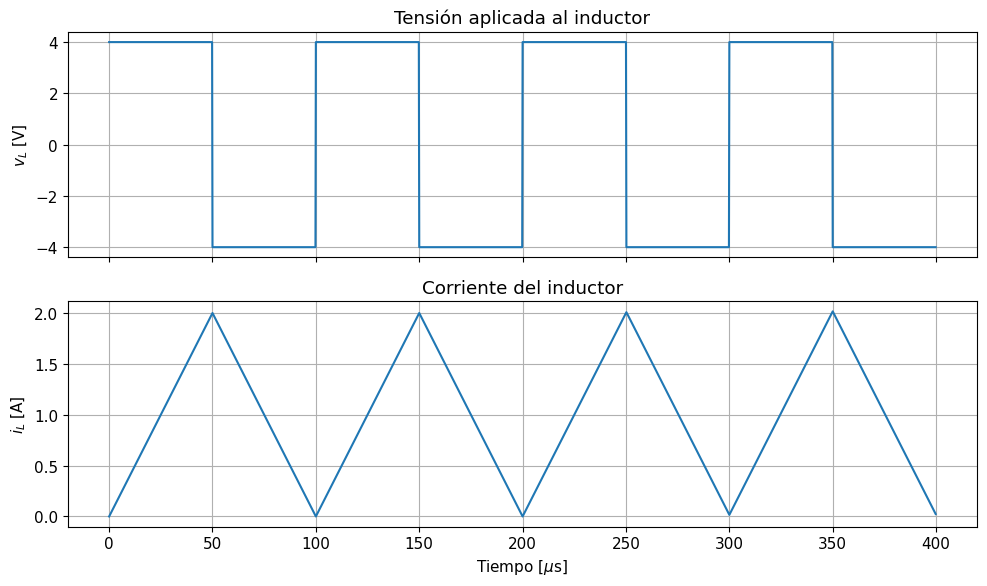

In [128]:
# Gráfica
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(t * 1e6, vL)
ax[0].set_ylabel("$v_L$ [V]")
ax[0].set_title("Tensión aplicada al inductor")
ax[0].grid(True)

ax[1].plot(t * 1e6, iL)
ax[1].set_ylabel("$i_L$ [A]")
ax[1].set_xlabel("Tiempo [$\\mu$s]")
ax[1].set_title("Corriente del inductor")
ax[1].grid(True)

plt.tight_layout()
plt.show()

# 5.1 Régimen periódico estacionario

Después de varios periodos, el circuito puede alcanzar un **régimen
periódico estacionario**, a veces denominado **régimen permanente**, **estado estacionario** o, simplemente **PSS** ( por sus siglas en inglés, *Periodic Stationary State*). En este régimen, la corriente del inductor se repite cada periodo$, i_L(t+T)=i_L(t)$. Por tanto, al finalizar un periodo el cambio neto de corriente debe ser cero, $\Delta i_L=0$.

$$
\Delta i_L
=
\frac{1}{L}\int_0^T v_L(t)\,dt
$$

Por tanto, en **PSS**:

$$
\boxed{
\left\langle V \right\rangle =
\int_0^T v_L(t)\,dt=0
}
$$

Esta es una propiedad fundamental de los inductores en régimen
periódico estacionario:

> **El área positiva de $v_L(t)$ debe compensarse con el área
> negativa durante cada periodo.**

En el ejemplo anterior:

$$
(+4\,V)(50\,\mu s)
+
(-4\,V)(50\,\mu s)
=0
$$

Por ello, la corriente aumenta $2\,A$ durante el primer intervalo
y disminuye $2\,A$ durante el segundo.

> **NO** es necesario que la tensión positiva y negativa tengan el mismo valor para que la corriente sea periódica. Lo que **debe** cumplirse es que **el área total** de la tensión aplicada al inductor durante un periodo sea **cero**,$\int_0^T v_L(t)\,dt=0$. Por ejemplo, puede ocurrir que durante un intervalo corto y durante uno largo la tensión cambie entre $v_L=6\,V
$ y $v_L=-2\,V$, respectivamente. Lo importante no es que las tensiones sean iguales, sino que sus áreas se compensen. Esta observación será fundamental cuando estudiemos convertidores conmutados y, en particular, el **ciclo de trabajo $D$**.

# 5.2 Circuito ngspice

Se utilizará únicamente una fuente de tensión con onda rectangular (+4V y -4V), un inductor (100 mH). La fuente aplicará +4V durante 50 us y -4V durante los siguiente 50 us. Es decir, se tiene un periodo T = 100us con ciclo de trabajo igual a 0.5




In [129]:
  #            L = 100 uH
  #      ┌──────UUUU──────┐
  #      │                │
  #  + ──┤                │
  # V1   │                │
  #      └────────────────┘

In [130]:
# Instalar ngspice para linux dentro del entorno COLAB
!apt-get update -qq
!apt-get install -y ngspice

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ngspice is already the newest version (36+ds-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 55 not upgraded.


In [131]:

# Comprobar la instalación solicitando la versión ngspice instalada
!ngspice -v

******
** ngspice-36 : Circuit level simulation program
** The U. C. Berkeley CAD Group
** Copyright 1985-1994, Regents of the University of California.
** Copyright 2001-2020, The ngspice team.
** Please get your ngspice manual from http://ngspice.sourceforge.net/docs.html
** Please file your bug-reports at http://ngspice.sourceforge.net/bugrep.html
** Creation Date: Mon Mar 11 21:44:53 UTC 2024
******


# Crear el netlist desde Python
Una de las ventajas de hacerlo de esta manera es que no necesitamos crear manualmente el archivo .sp como tampoco abandonar el cuaderno COLAB.

In [132]:
netlist = r"""
* ============================================================
* Ejemplo: tension rectangular aplicada a un inductor
* ============================================================

.title Inductor with bipolar square-wave voltage

.param Lval = 100u
.param Tsw  = 100u
.param Duty = 0.5

V1 in 0 PULSE(-4 4 10n 1n 1n {Duty*Tsw} {Tsw})
L1 in 0 {Lval}

.tran 0.1u 400u uic

.control
run
set wr_singlescale
wrdata inductor_results.txt time v(in) i(L1)
.endc

.end
"""

with open("inductor_example.sp", "w") as f:
    f.write(netlist)

print("Netlist creado correctamente.")

Netlist creado correctamente.


In [133]:
# Comprobar contenido del script ngspice
!cat inductor_example.sp


* ============================================================
* Ejemplo: tension rectangular aplicada a un inductor
* ============================================================

.title Inductor with bipolar square-wave voltage

.param Lval = 100u
.param Tsw  = 100u
.param Duty = 0.5

V1 in 0 PULSE(-4 4 10n 1n 1n {Duty*Tsw} {Tsw})
L1 in 0 {Lval} 

.tran 0.1u 400u uic

.control
run
set wr_singlescale
wrdata inductor_results.txt time v(in) i(L1)
.endc

.end


In [134]:
# Ejecutar ngspice. La opción -b significa batch mode, ngspice no abre su interfaz interactiva; simplemente ejecuta el circuito y termina.
# Esto es especialmente conveniente para nuestro entorno de trabajo.
!ngspice -b inductor_example.sp


No compatibility mode selected!


Circuit: Inductor with bipolar square-wave voltage

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using transient initial conditions

No. of Data Rows : 4123
Note: No ".plot", ".print", or ".fourier" lines; no simulations run


In [135]:
# Comprobar que se generó el resultado, debe aparecer fichero .txt
!ls -lh

total 3.6M
-rw-r--r-- 1 root root   463 Sep  1 08:07 inductor_example.sp
-rw-r--r-- 1 root root  262K Sep  1 08:07 inductor_results.txt
-rw-r--r-- 1 root root   427 Sep  1 07:43 rl_charge.sp
-rw-r--r-- 1 root root  788K Sep  1 07:43 rl_charge.txt
-rw-r--r-- 1 root root   395 Sep  1 07:43 rl_discharge.sp
-rw-r--r-- 1 root root  319K Sep  1 07:43 rl_discharge.txt
-rw-r--r-- 1 root root   847 Sep  1 07:43 rl_nmos.sp
-rw-r--r-- 1 root root  1.3M Sep  1 07:43 rl_nmos.txt
-rw-r--r-- 1 root root   720 Sep  1 07:43 rl_switch.sp
-rw-r--r-- 1 root root 1008K Sep  1 07:43 rl_switch.txt
drwxr-xr-x 1 root root  4.0K Aug 24 13:21 sample_data


In [136]:
# Comprobar contenido del fichero .txt
!head -10 inductor_results.txt

 1.00000000e-10  1.00000000e-10 -4.00000000e+00 -4.00000000e-06 
 2.00000000e-10  2.00000000e-10 -4.00000000e+00 -8.00000000e-06 
 4.00000000e-10  4.00000000e-10 -4.00000000e+00 -1.60000000e-05 
 8.00000000e-10  8.00000000e-10 -4.00000000e+00 -3.20000000e-05 
 1.60000000e-09  1.60000000e-09 -4.00000000e+00 -6.40000000e-05 
 3.20000000e-09  3.20000000e-09 -4.00000000e+00 -1.28000000e-04 
 6.40000000e-09  6.40000000e-09 -4.00000000e+00 -2.56000000e-04 
 1.00000000e-08  1.00000000e-08 -4.00000000e+00 -4.00000000e-04 
 1.01000000e-08  1.01000000e-08 -3.20000000e+00 -4.03200000e-04 
 1.03000000e-08  1.03000000e-08 -1.60000000e+00 -4.08000000e-04 


In [137]:
# Leer los resultados con numpy/Python, ngspice deja de ser el entorno de análisis.
data = np.loadtxt("inductor_results.txt")
print(data.shape)

(4123, 4)


In [138]:
# Se realiza una primera inspección
for i in range(min(5, len(data))):
    print(data[i])

[ 1.e-10  1.e-10 -4.e+00 -4.e-06]
[ 2.e-10  2.e-10 -4.e+00 -8.e-06]
[ 4.0e-10  4.0e-10 -4.0e+00 -1.6e-05]
[ 8.0e-10  8.0e-10 -4.0e+00 -3.2e-05]
[ 1.6e-09  1.6e-09 -4.0e+00 -6.4e-05]


In [139]:
# Ejemplo suponiendo:
# columna 0 -> tiempo
# columna 2 -> vL
# columna 3 -> iL

time = data[:, 0]
vL = data[:, 2]
iL = data[:, 3]

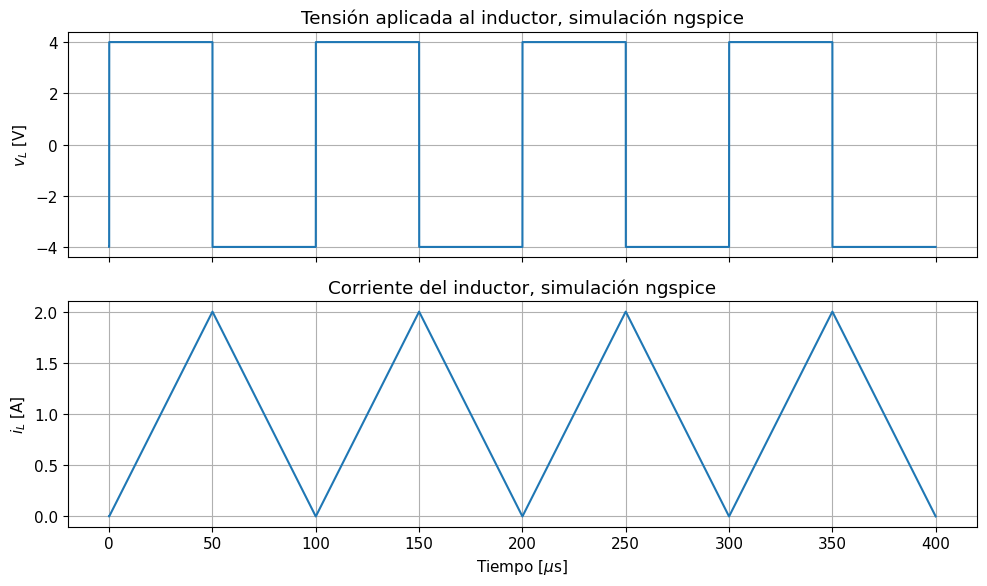

In [140]:
# Gráfica
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(time * 1e6, vL)
ax[0].set_ylabel("$v_L$ [V]")
ax[0].set_title("Tensión aplicada al inductor, simulación ngspice")
ax[0].grid(True)

ax[1].plot(time * 1e6, iL)
ax[1].set_ylabel("$i_L$ [A]")
ax[1].set_xlabel("Tiempo [$\\mu$s]")
ax[1].set_title("Corriente del inductor, simulación ngspice")
ax[1].grid(True)

plt.tight_layout()
plt.show()

# 6 Ejemplo: Carga y descarga de un inductor en un circuito RL

Consideremos el circuito serie RL: $V_s \longrightarrow R \longrightarrow L$.
La tensión en la resistencia, $v_R$,  y en el inductor, $v_L$ se obtienen a partir de $v_R=Ri_L$ y $v_L=L\frac{di_L}{dt}$, respectivamente. Por tanto:

$$
\boxed{
V_s=Ri_L+L\frac{di_L}{dt}
}
$$

Reordenando:

$$
\boxed{
\frac{di_L}{dt}+\frac{R}{L}i_L
=
\frac{V_s}{L}
}
$$

Esta es una ecuación diferencial lineal de primer orden. Definimos la constante de tiempo del circuito RL como:

$$
\boxed{
\tau=\frac{L}{R}
}
$$

## 6.1 Carga del inductor


La constante de tiempo determina la rapidez con la que evoluciona la corriente del inductor. Para $L=100\,\mu\mathrm{H}$, $R=1\,\Omega$ se tiene que $\tau=
\frac{100\times10^{-6}}{1} =100\,\mu\mathrm{s}$.  Después de aproximadamente $5\tau$, el transitorio prácticamente ha desaparecido. Supongamos que inicialmente $i_L(0)=0$ y que aplicamos una tensión constante $V_s=V$. La solución general de la ecuación diferencial está formada por una solución particular y una solución homogénea.

La solución homogénea supone una solución de la forma $i_h(t) = C_1 e^{st}$:

$$
i_h(t)=C_1e^{-Rt/L} =C_1e^{-t/\tau}, \quad \tau=\frac{L}{R}
$$

La solución particular supone una corriente constante $I=\frac{V}{R}$.

La solución completa es:

$$
i_L(t)=
\frac{V}{R}
+
C_1e^{-t/\tau}
$$

Aplicando la condición inicial $i_L(0)=0$, se obtiene el valor de $C_1=-\frac{V}{R}$. Finalmente la solución completa se escribe como:

$$
\boxed{
i_L(t)=
\frac{V}{R}
\left(
1-e^{-t/\tau}
\right)
}
$$

Esta es la ecuación de carga del inductor y sustituyendo los valores del ejemplo se tiene $i_L(t)=4\left(1-e^{-t/100}\right)$. Por tanto, después de aproximadamente $5\tau$, $i_L(5\tau)\approx3.97\,\mathrm{A}$, podemos considerar que el circuito ha alcanzado prácticamente el régimen permanente.

## 6.2 Descarga del inductor

Supongamos ahora que el inductor se encuentra inicialmente cargado, $i_L(0)=I_0$, y desconectamos la fuente,$V_s=0$. La ecuación diferencial queda:

$$
\frac{di_L}{dt}+\frac{R}{L}i_L=0
$$

La solución es $i_L(t)=C_1e^{-t/\tau}$ y para encontrar el valor de la constante simplemente se utiliza $i_L(0)=I_0$ lo que conduce a $C_1=I_0$. Por tanto:

$$
\boxed{
i_L(t)=I_0e^{-t/\tau}
}
$$

Es evidente que la corriente no puede desaparecer instantáneamente. El inductor libera progresivamente la energía almacenada, $E_L=\frac{1}{2}Li_L^2$. La energía termina disipándose en la resistencia.

In [141]:
# Parámetros del circuito
V           = 4.0          # V
R           = 1.0          # ohm
L           = 100e-6       # H

# Constante de tiempo
tau         = L / R

# Corriente final de carga
I_final     = V / R

In [142]:
# Vector de tiempo: 0 a 5 tau
t           = np.linspace(0, 5*tau, 1000, endpoint=False)

In [143]:
# Solución analítica de carga
i_charge    = (V/R) * (1 - np.exp(-t/tau))

In [144]:
# Mostrar algunos valores
for multiplier in range(6):
    ti = multiplier * tau
    ii = (V/R) * (1 - np.exp(-ti/tau))
    print(f"t = {ti*1e6:7.1f} us   "  f"iL = {ii:7.4f} A")

t =     0.0 us   iL =  0.0000 A
t =   100.0 us   iL =  2.5285 A
t =   200.0 us   iL =  3.4587 A
t =   300.0 us   iL =  3.8009 A
t =   400.0 us   iL =  3.9267 A
t =   500.0 us   iL =  3.9730 A


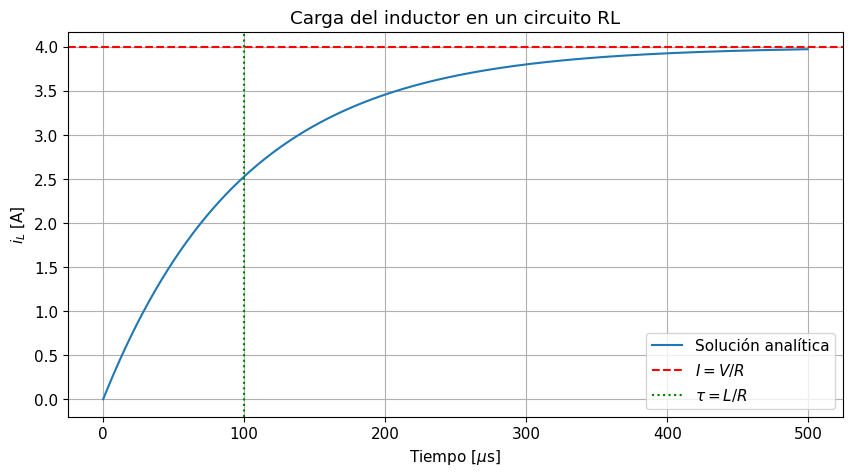

In [145]:
plt.plot(t * 1e6,  i_charge, label="Solución analítica")
plt.axhline(I_final, linestyle="--", label=r"$I=V/R$", color='r')
plt.axvline(tau * 1e6, linestyle=":", label=r"$\tau=L/R$", color='g')

plt.xlabel("Tiempo [$\\mu$s]")
plt.ylabel("$i_L$ [A]")
plt.title("Carga del inductor en un circuito RL")
plt.grid(True)
plt.legend()

plt.show()

In [146]:
# Corriente inicial de descarga
I0          = I_final

# Tiempo de descarga
t_discharge = np.linspace(0, 5*tau, 1000)

# Solución analítica
i_discharge = I0 * np.exp(-t_discharge/tau)

print(f"Corriente inicial de descarga: {I0:.2f} A")
print(f"Corriente después de 1 tau: "
      f"{I0*np.exp(-1):.4f} A")
print(f"Corriente después de 5 tau: "
      f"{I0*np.exp(-5):.4f} A")

Corriente inicial de descarga: 4.00 A
Corriente después de 1 tau: 1.4715 A
Corriente después de 5 tau: 0.0270 A


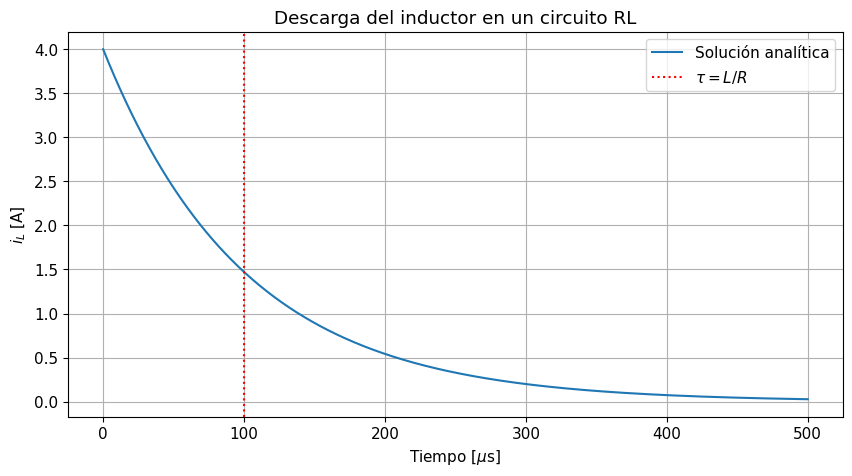

In [147]:
plt.figure(figsize=(10, 5))

plt.plot(t_discharge * 1e6, i_discharge, label="Solución analítica")
plt.axvline(tau * 1e6, linestyle=":", label=r"$\tau=L/R$", color='r')
plt.xlabel("Tiempo [$\\mu$s]")
plt.ylabel("$i_L$ [A]")
plt.title("Descarga del inductor en un circuito RL")
plt.grid(True)
plt.legend()

plt.show()

In [148]:
# Tiempo de carga
t_c = np.linspace(0, 5*tau, 1000)

# Corriente de carga
i_c = I_final * (1 - np.exp(-t_c/tau))

# Tiempo de descarga
t_d = np.linspace(0, 5*tau, 1000)

# Corriente de descarga
i_d = I_final * np.exp(-t_d/tau)

# Unimos ambos intervalos
t_total = np.concatenate([t_c, 5*tau + t_d])
i_total = np.concatenate([i_c, i_d])

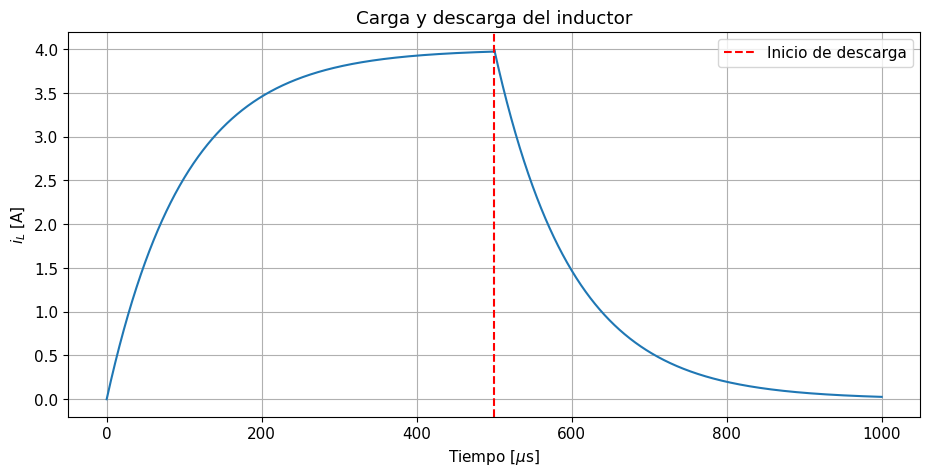

In [149]:

plt.figure(figsize=(11, 5))

plt.plot( t_total * 1e6, i_total)
plt.axvline(5*tau * 1e6, linestyle="--", label="Inicio de descarga", color='r')
plt.xlabel("Tiempo [$\\mu$s]")
plt.ylabel("$i_L$ [A]")
plt.title("Carga y descarga del inductor")
plt.grid(True)
plt.legend()

plt.show()

In [150]:
netlist_charge = r"""
* ============================================================
* Carga de un inductor en un circuito RL
* ============================================================

.title RL - Carga del inductor

.param Vval = 4
.param Rval = 1
.param Lval = 100u

V1 in 0 DC {Vval}

R1 in out {Rval}

L1 out 0 {Lval}

.tran 0.1u 500u uic

.control
run
set filetype=ascii
wrdata rl_charge.txt time v(in) v(out) v(in,out) i(L1)
.endc

.end
"""

with open("rl_charge.sp", "w") as f:
    f.write(netlist_charge)

print("Netlist de carga creado.")

Netlist de carga creado.


In [151]:
result = subprocess.run(["ngspice", "-b", "rl_charge.sp"], capture_output=True, text=True)
print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)


No compatibility mode selected!


Circuit: RL - Carga del inductor

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using transient initial conditions

No. of Data Rows : 5011

STDERR:
Note: No ".plot", ".print", or ".fourier" lines; no simulations run



In [152]:
print("Archivo netlist:", os.path.exists("rl_charge.sp"))
print("Archivo resultados:", os.path.exists("rl_charge.txt"))

if os.path.exists("rl_charge.txt"):
    print("\nPrimeras líneas:")
    with open("rl_charge.txt", "r") as f:
        for _ in range(5):
            print(f.readline().strip())

Archivo netlist: True
Archivo resultados: True

Primeras líneas:
1.00000000e-09  1.00000000e-09  1.00000000e-09  4.00000000e+00  1.00000000e-09  3.99996000e+00  1.00000000e-09  3.99996000e-05  1.00000000e-09  3.99996000e-05
2.00000000e-09  2.00000000e-09  2.00000000e-09  4.00000000e+00  2.00000000e-09  3.99992000e+00  2.00000000e-09  7.99988000e-05  2.00000000e-09  7.99988000e-05
4.00000000e-09  4.00000000e-09  4.00000000e-09  4.00000000e+00  4.00000000e-09  3.99984000e+00  4.00000000e-09  1.59996400e-04  4.00000000e-09  1.59996400e-04
8.00000000e-09  8.00000000e-09  8.00000000e-09  4.00000000e+00  8.00000000e-09  3.99968001e+00  8.00000000e-09  3.19986800e-04  8.00000000e-09  3.19986800e-04
1.60000000e-08  1.60000000e-08  1.60000000e-08  4.00000000e+00  1.60000000e-08  3.99936005e+00  1.60000000e-08  6.39948403e-04  1.60000000e-08  6.39948403e-04


In [153]:
# Si wrdata está usando el formato de pares:
# 0 → tiempo
# 1 → tiempo

# 2 → tiempo
# 3 → v(in)

# 4 → tiempo
# 5 → v(out)

# 6 → tiempo
# 7 → v(in,out)

# 8 → tiempo
# 9 → i(L1)
data = np.loadtxt("rl_charge.txt", comments="*")
n_columns = data.shape[1]
print(f"Número de columnas: {n_columns}")
print("Dimensiones:", data.shape)
print(data[:5])

Número de columnas: 10
Dimensiones: (5011, 10)
[[1.00000000e-09 1.00000000e-09 1.00000000e-09 4.00000000e+00
  1.00000000e-09 3.99996000e+00 1.00000000e-09 3.99996000e-05
  1.00000000e-09 3.99996000e-05]
 [2.00000000e-09 2.00000000e-09 2.00000000e-09 4.00000000e+00
  2.00000000e-09 3.99992000e+00 2.00000000e-09 7.99988000e-05
  2.00000000e-09 7.99988000e-05]
 [4.00000000e-09 4.00000000e-09 4.00000000e-09 4.00000000e+00
  4.00000000e-09 3.99984000e+00 4.00000000e-09 1.59996400e-04
  4.00000000e-09 1.59996400e-04]
 [8.00000000e-09 8.00000000e-09 8.00000000e-09 4.00000000e+00
  8.00000000e-09 3.99968001e+00 8.00000000e-09 3.19986800e-04
  8.00000000e-09 3.19986800e-04]
 [1.60000000e-08 1.60000000e-08 1.60000000e-08 4.00000000e+00
  1.60000000e-08 3.99936005e+00 1.60000000e-08 6.39948403e-04
  1.60000000e-08 6.39948403e-04]]


In [154]:
time_ng = data[:, 0]
vin_ng = data[:, 3]
vout_ng = data[:, 5]
vl_ng = data[:, 7]
il_ng = data[:, 9]

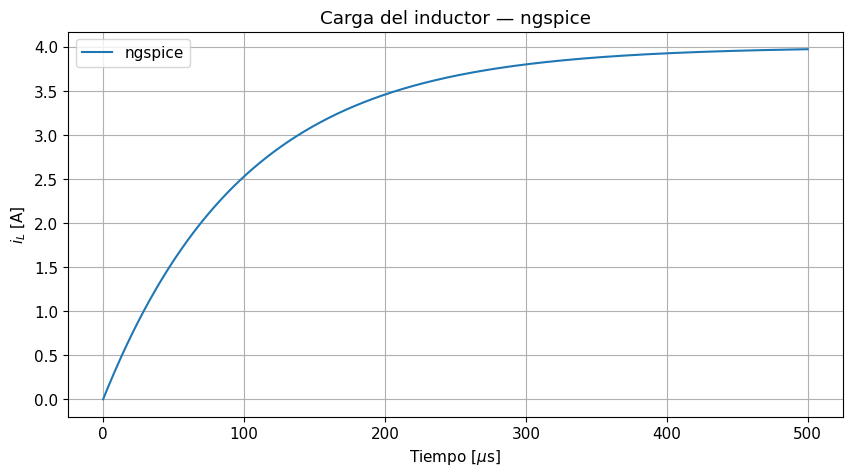

In [155]:
plt.figure(figsize=(10, 5))

plt.plot(time_ng * 1e6, il_ng, label="ngspice")
plt.xlabel("Tiempo [$\\mu$s]")
plt.ylabel("$i_L$ [A]")
plt.title("Carga del inductor — ngspice")
plt.grid(True)
plt.legend()

plt.show()

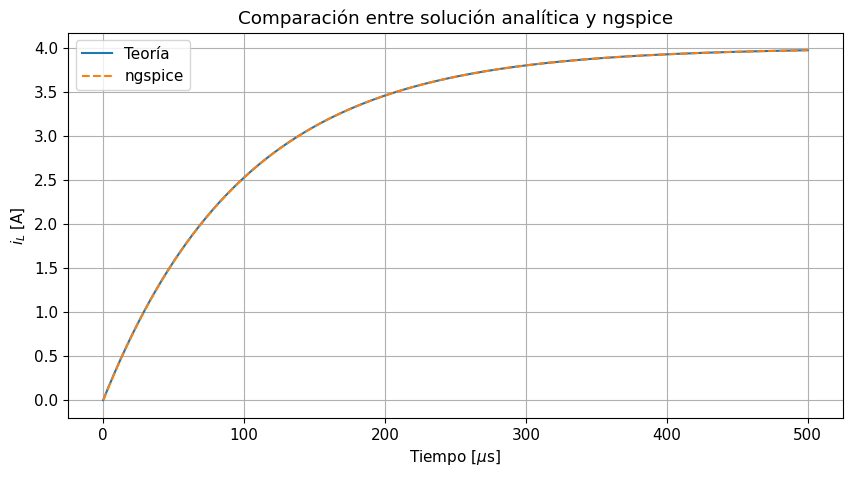

In [156]:
# Solución analítica evaluada en los tiempos de ngspice
i_theory = (V/R) * (1 - np.exp(-time_ng/tau))

plt.figure(figsize=(10, 5))

plt.plot(time_ng * 1e6, i_theory, label="Teoría")
plt.plot(time_ng * 1e6, il_ng, linestyle="--", label="ngspice")

plt.xlabel("Tiempo [$\\mu$s]")
plt.ylabel("$i_L$ [A]")
plt.title("Comparación entre solución analítica y ngspice")
plt.grid(True)
plt.legend()

plt.show()

In [157]:
# Calcular el error
error = il_ng - i_theory
print("Error máximo absoluto:", np.max(np.abs(error)), "A")
print("Error RMS:", np.sqrt(np.mean(error**2)),   "A")

Error máximo absoluto: 1.2417036510115054e-07 A
Error RMS: 7.239694749332042e-08 A


In [158]:
# Verificar la constante de tiempo con ngspice
target = I_final * (1 - np.exp(-1))
print(f"63.21 % de I_final = {target:.6f} A")

63.21 % de I_final = 2.528482 A


In [159]:
idx_tau = np.argmin(np.abs(il_ng - target))
tau_sim = time_ng[idx_tau]

print(f"tau teórica = {tau*1e6:.3f} us")
print(f"tau simulada = {tau_sim*1e6:.3f} us")

tau teórica = 100.000 us
tau simulada = 99.996 us


In [160]:
# Verificar el valor final
I_final_theory = V/R

# Tomamos los últimos puntos de la simulación
I_final_sim = np.mean(il_ng[-100:])

print(f"I_final teórica = {I_final_theory:.6f} A")
print(f"I_final ngspice = {I_final_sim:.6f} A")

I_final teórica = 4.000000 A
I_final ngspice = 3.971696 A


In [161]:
netlist_discharge = r"""
* ============================================================
* Descarga de un inductor en un circuito RL
* ============================================================

.title RL - Descarga del inductor

.param Rval = 1
.param Lval = 100u
V1 in 0 DC 0
R1  in out {Rval}
L1 out 0 {Lval} ic=4

.tran 0.1u 500u uic

.control
run
set filetype=ascii
wrdata rl_discharge.txt time i(L1)
.endc

.end
"""

with open("rl_discharge.sp", "w") as f:
    f.write(netlist_discharge)

print("Netlist de descarga creado.")

Netlist de descarga creado.


In [162]:
result = subprocess.run(["ngspice", "-b", "rl_discharge.sp"], capture_output=True, text=True)
print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)


No compatibility mode selected!


Circuit: RL - Descarga del inductor

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using transient initial conditions

No. of Data Rows : 5011

STDERR:
Note: No ".plot", ".print", or ".fourier" lines; no simulations run



In [163]:
data_d = np.loadtxt("rl_discharge.txt", comments="*")
print(data_d.shape)

(5011, 4)


In [164]:
time_d = data_d[:, 2]
il_d = data_d[:, 3]

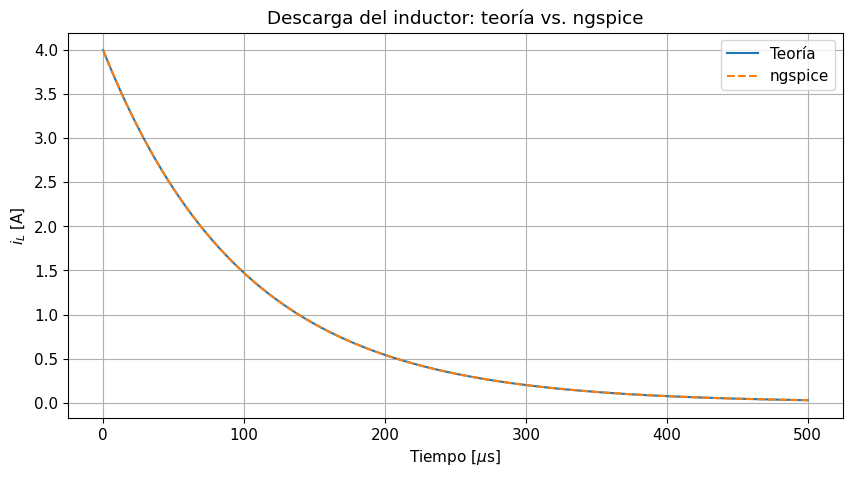

In [165]:
i_discharge_theory = I0 * np.exp(-time_d/tau)

plt.figure(figsize=(10, 5))

plt.plot(time_d * 1e6, i_discharge_theory, label="Teoría")
plt.plot(time_d * 1e6, il_d, linestyle="--", label="ngspice")

plt.xlabel("Tiempo [$\\mu$s]")
plt.ylabel("$i_L$ [A]")
plt.title("Descarga del inductor: teoría vs. ngspice")
plt.grid(True)
plt.legend()

plt.show()

In [166]:
error_discharge = il_d - i_discharge_theory

print("Error máximo:", np.max(np.abs(error_discharge)), "A")

print("Error RMS:", np.sqrt(np.mean(error_discharge**2)), "A")

Error máximo: 1.2417036532319514e-07 A
Error RMS: 7.23674843823898e-08 A


## 6.3 Conexión con una onda cuadrada periódica

La onda cuadrada utilizada anteriormente alternaba entre $+V$ y $-V$.

* Durante el intervalo positivo la corriente obedece:

$$
\boxed{
i_L(t)=
4+
\left[
i_L(t_0)-4
\right]
e^{-(t-t_0)/\tau}
}
$$

* Durante el intervalo negativo la corriente obedece:

$$
\boxed{
i_L(t)=
-4+
\left[
i_L(t_1)+4
\right]
e^{-(t-t_1)/\tau}
}
$$

Por tanto, en presencia de una resistencia, la corriente del inductor
no es exactamente triangular. Está formada por sucesiones de **curvas exponenciales**. Cuando $R$ es pequeña o $L$ muy grande, la constante de tiempo $\tau=\frac LR$ se hace grande y la respuesta exponencial se **aproxima a una recta** durante cada intervalo. Esta es la razón por la que el comportamiento de un inductor ideal puede representarse mediante rampas de corriente.

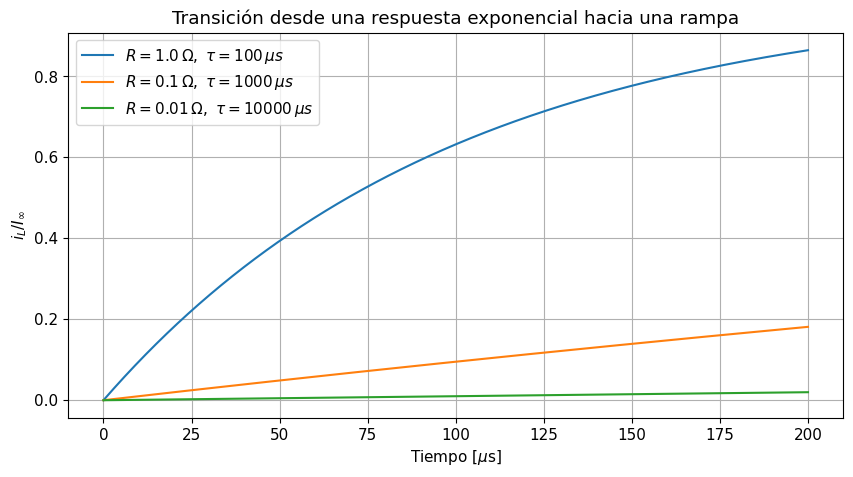

In [167]:
R_values = [1.0, 0.1, 0.01]
t = np.linspace(0, 200e-6, 1000)

plt.figure(figsize=(10, 5))
for R_test in R_values:
    tau_test = L / R_test
    i_norm = 1 - np.exp(-t/tau_test)
    plt.plot(t * 1e6, i_norm, label=fr"$R={R_test}\,\Omega,\ " fr"\tau={tau_test*1e6:.0f}\,\mu s$"    )

plt.xlabel("Tiempo [$\\mu$s]")
plt.ylabel(r"$i_L/I_\infty$")
plt.title("Transición desde una respuesta exponencial hacia una rampa")
plt.grid(True)
plt.legend()

plt.show()

## 7 Interruptor ideal

Un interruptor ideal puede representar dos estados.

* Cuando el interruptor está cerrado, $R_{ON}\approx0$. El interruptor se comporta aproximadamente como un cortocircuito.

* Cuando el interruptor está abierto, $R_{OFF}\rightarrow\infty$. El interruptor se comporta aproximadamente como un circuito abierto.

En SPICE se representa un interruptor **controlado** mediante cualquier nombre, por ejemplo, $\texttt{S1}$, y definir sus características mediante un modelo:
$$
\texttt{.model} \quad \texttt{SWMOD} \quad \texttt{SW(RON=1m ROFF=1Meg VT=2)}
$$

El estado del interruptor depende de una tensión de control $V_{control}$. Así, si $V_{control} > \texttt{VT}$ el interruptor está cerrado, caso contrario, $V_{control} < \texttt{VT}$, el interruptor está abierto. Se utiliza una segunda fuente de tensión para controlar el interruptor:

$$ \texttt{Vgate} \quad \texttt{gate} \quad 0 \quad  \texttt{PULSE(0 5 0 1n 1n 50u 100u)} $$

Donde $\texttt{V_{LOW}} = 0V$,  $\texttt{V_{HIGH}} = 5V$, $\texttt{DELAY} = 0$, $\texttt{TR}= 1n s$, $\texttt{TF}= 1n s$, $\texttt{T_{ON}} =50\mu s$ y $\texttt{T}=100\mu s$

In [168]:
netlist_switch = r"""
* ============================================================
* Circuito RL con interruptor ideal
* ============================================================

.title RL with ideal switch

.param Vval  = 4
.param Rval  = 1
.param Lval  = 100u
.param Tsw   = 100u
.param Duty  = 0.5

* Fuente principal
V1 in 0 DC {Vval}

* Señal de control
Vgate gate 0 PULSE(0 5 0 1n 1n {Duty*Tsw} {Tsw})

* Resistencia
R1 in n1 {Rval}

* Inductor
L1 n1 out {Lval}

* Interruptor controlado
S1 out 0 gate 0 SWMOD

* Modelo del interruptor
.model SWMOD SW(RON=1m ROFF=1Meg VT=2)

* Simulación transitoria
.tran 0.1u 500u

.control
run

set filetype=ascii
wrdata rl_switch.txt time v(in) v(gate) v(out) v(n1,out) i(L1)

.endc

.end
"""

with open("rl_switch.sp", "w") as f:
    f.write(netlist_switch)

print("Netlist creado correctamente.")

Netlist creado correctamente.


In [169]:
result = subprocess.run(["ngspice", "-b", "rl_switch.sp"], capture_output=True, text=True)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)


No compatibility mode selected!


Circuit: RL with ideal switch

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


Initial Transient Solution
--------------------------

Node                                   Voltage
----                                   -------
in                                           4
gate                                         0
n1                                           4
out                                          4
l1#branch                                4e-06
vgate#branch                                 0
v1#branch                               -4e-06


No. of Data Rows : 5348

STDERR:
Note: No ".plot", ".print", or ".fourier" lines; no simulations run



In [170]:
print("Archivo de resultados:",  os.path.exists("rl_switch.txt"))

Archivo de resultados: True


In [171]:
data = np.loadtxt("rl_switch.txt", comments="*")
print("Shape:", data.shape)

Shape: (5348, 12)


In [172]:
time = data[:, 0]
vin = data[:, 3]
vgate = data[:, 5]
vout = data[:, 7]
vl = data[:, 9]
il = data[:, 11]

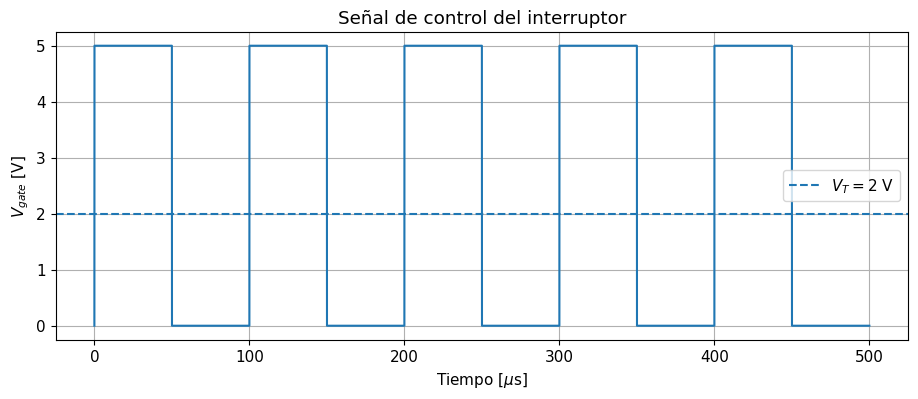

In [173]:
plt.figure(figsize=(11, 4))

plt.plot(time * 1e6, vgate)

plt.axhline(2, linestyle="--", label=r"$V_T=2$ V")

plt.xlabel("Tiempo [$\\mu$s]")
plt.ylabel("$V_{gate}$ [V]")
plt.title("Señal de control del interruptor")
plt.grid(True)
plt.legend()

plt.show()

In [174]:
# Estado ON/OFF
switch_on = vgate > 2
for t_us in [25, 75, 125, 175]:
    idx = np.argmin(np.abs(time*1e6 - t_us) )
    state = "ON" if switch_on[idx] else "OFF"
    print( f"t = {time[idx]*1e6:7.2f} us   "  f"Vgate = {vgate[idx]:.2f} V   "  f"Switch = {state}"    )

t =   25.04 us   Vgate = 5.00 V   Switch = ON
t =   75.04 us   Vgate = 0.00 V   Switch = OFF
t =  125.01 us   Vgate = 5.00 V   Switch = ON
t =  175.04 us   Vgate = 0.00 V   Switch = OFF


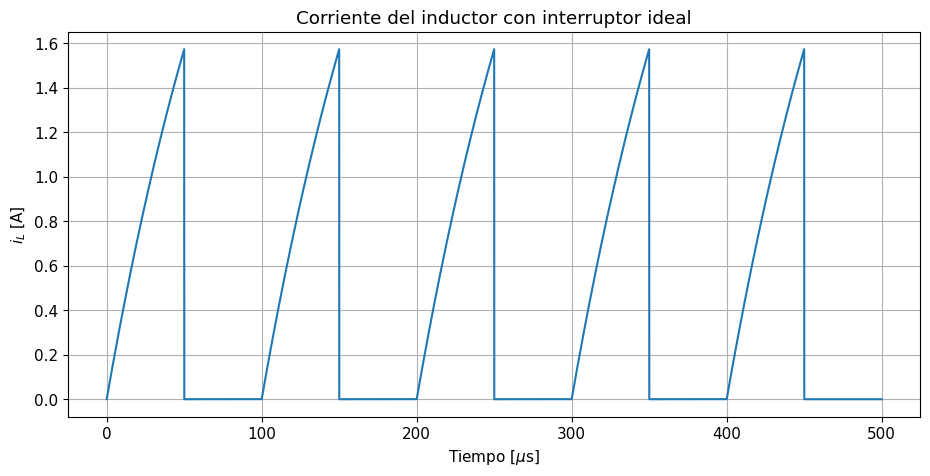

In [175]:
plt.figure(figsize=(11, 5))

plt.plot(time * 1e6, il)

plt.xlabel("Tiempo [$\\mu$s]")
plt.ylabel("$i_L$ [A]")
plt.title("Corriente del inductor con interruptor ideal")
plt.grid(True)

plt.show()

Solución: Añadir un Diodo de Freewheeling (Rueda Libre)

# 7.1. Diagnóstico del Circuito

Como se observa el circuito RL adolece de problemas en la carga y en la descarga. El fallo se debe a la **naturaleza física del inductor** y a la **topología del circuito**:

1. **Carga Incompleta:**
   La constante de tiempo del circuito es $\tau = \frac{L}{R} = \frac{100\ \mu\text{H}}{1\ \Omega} = 100\ \mu\text{s}$. Para una carga/descarga completa se requieren $5\tau = 500\ \mu\text{s}$. El ciclo de trabajo dura solo $50\ \mu\text{s}$ ($\frac{1}{2}\tau$), interrumpiendo el proceso prematuramente.

2. **Picos de Tensión ($V_{\text{out}} \approx \text{MV}$).**
   Antes de abrir el interruptor, el inductor tiene una corriente $i_L(t_0)=I_0$. Un inductor se opone a cambios bruscos de corriente,$v_L(t) = L \frac{di(t)}{dt}$.  Al abrir el interruptor $S_1$, la resistencia pasa abruptamente a $R_{\text{OFF}} = 1\text{ M}\Omega$. Como la corriente no puede cambiar a cero instantáneamente, el inductor genera un pulso de tensión extremo para forzar el paso de corriente:
   $$V_{\text{out}} \approx I_L \cdot R_{\text{OFF}} \approx 4\text{ A} \cdot 1\text{ M}\Omega = 4\text{ MV}$$



# 7.2. Solución

1. **Ajustar el Período ($T_{\text{sw}}$):** Aumentar el tiempo en estado ALTO a $500\ \mu\text{s}$ ($5\tau$) para permitir la carga completa, y el estado BAJO a $500\ \mu\text{s}$ ($5\tau$) para observar la descarga.
2. **Añadir un Diodo de Rueda Libre (*Freewheeling*):** Proporciona un camino cerrado de retorno para que la corriente del inductor circule libremente y se disipe en $R_1$ al abrir el interruptor.

Por tanto:

$$
\boxed{
\text{El inductor necesita un camino para su corriente}
}
$$

Esta observación es fundamental en electrónica de potencia. El siguiente elemento que debemos introducir será el diodo de rueda
libre.



In [176]:
      #                     L      R
      #   ┌───SW──────┌───UUUU────/\/\/──┐
      #   │           │                  │
      #  V1           D1                 │
      #   │           │                  │
      #   └───────────└──────────────────┘
      #               ↑
      #      Diodo de rueda libre

## El diodo de rueda libre


Antes de abrir el interruptor, el inductor tiene una corriente, $i_L(t_0)=I_0$.
Cuando el interruptor se abre, la corriente del inductor no puede cambiar instantáneamente, $v_L=L\frac{di_L}{dt}$. Si el circuito intentara imponer $i_L(t_0^+)=0$ entonces el cambio de corriente sería extremadamente rápido, necesitando una tensión muy elevada para producir ese cambio brusco.

Por ello se proporciona un camino alternativo para la corriente. Este camino puede implementarse mediante un diodo denominado $\textbf{diodo de rueda libre}$. La secuencia es:

$$
\boxed{
\text{interruptor ON}
\rightarrow
\text{inductor almacena energía}
}
$$

y posteriormente:

$$
\boxed{
\text{interruptor OFF}
\rightarrow
\text{diodo ON}
\rightarrow
\text{inductor libera energía}
}
$$



Cuando el interruptor está cerrado, la fuente entrega energía al circuito y el inductor almacena parte de ella, $E_L=\frac{1}{2}Li_L^2$. Cuando el interruptor se abre, el inductor continúa entregando energía. El diodo proporciona un camino para que esa **energía continúe circulando** por el circuito, manteniendo la continuidad de la corriente del inductor.


## Transistor MOSFET como interruptor

 Con el interruptor ideal, cuando el interruptor estaba cerrado:$R_{ON}\approx0$ y por tanto:$V_{SW}\approx0$. La fuente de $4$ V podía aplicarse prácticamente por completo al circuito $RL$. En un circuito real necesitamos un dispositivo electrónico que pueda ser controlado eléctricamente. Un MOSFET puede utilizarse como interruptor controlado mediante su terminal de puerta ($\textit{gate}$). Al sustituir el interruptor ideal por un NMOS se tiene que el NMOS presenta una tensión $V_{DS}>0$ cuando conduce, y por tanto$V_{IN}=V_{DS}+V_R+V_L$

 * Durante el régimen estacionario $V_L\approx0$ y entonces $ V_{IN}\approx V_{DS}+V_R$

* Solo parte de la tensión de la fuente aparece ahora sobre el NMOS, con lo cual $ i_{L,NMOS}<i_{L,ideal}$

En la sustitución del NMOS por el interruptor ideal se ha mantenido deliberadamente la misma topología. En en lado del $D$ el NMOS está conectado a la fuente y en el lado de $S$ al circuito RL. La tensión $V_{GS}=V_G-V_S$ ya no se corresponde con un valor entre 0 y 5V dado que $V_S=v(in)$, $
V_{GS}=V_G-v(in)$. Lo importante para el MOSFET es la diferencia entre puerta y source.

In [177]:
netlist_nmos = r"""
* ============================================================
* Circuito RL con NMOS CMOS como interruptor
* ============================================================

* Parámetros
.param Vval = 4
.param Rval = 1
.param Lval = 100u
.param Tsw  = 1000u
.param Duty = 0.5

* Fuente principal
V1 in_dc 0 DC {Vval}
* MOSFET NMOS como SW: D G S B
M1 in_dc gate in 0 NMOS_SW W=100u L=1u
* Circuito RL
L1 in out {Lval}
R1 out 0 {Rval}

* Diodo de rueda libre. Ánodo->GND y Cátodo->nodo in
D1 0 in DMOD
* Señal de control de puerta
Vgate gate 0 PULSE(0 5 0 10n 10n {Duty*Tsw} {Tsw})

* MODELO
.model NMOS_SW NMOS(LEVEL=1 VTO=2 KP=10m LAMBDA=0.01)
.model DMOD D(IS=1n N=1)
*.model DMOD D(IS=1e-14 N=1 RS=10m BV=1000)

* Análisis transitorio
.tran 0.1u 1m
.control
run

set filetype=ascii
wrdata rl_nmos.txt time v(out) v(in,out) i(L1)
.endc
.end
"""

with open("rl_nmos.sp", "w") as f:
    f.write(netlist_nmos)

print("Netlist creado correctamente.")

Netlist creado correctamente.


In [178]:
result = subprocess.run(["ngspice", "-b", "rl_nmos.sp"], capture_output=True, text=True)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)


No compatibility mode selected!


Circuit: 

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


Initial Transient Solution
--------------------------

Node                                   Voltage
----                                   -------
in_dc                                        4
gate                                         0
in                                 4.58262e-26
out                                4.58262e-26
l1#branch                          4.58262e-26
vgate#branch                                 0
v1#branch                            -4.01e-12


No. of Data Rows : 10031

STDERR:
Note: No ".plot", ".print", or ".fourier" lines; no simulations run



In [179]:
print("Archivo de resultados:",  os.path.exists("rl_nmos.txt"))

Archivo de resultados: True


In [180]:
data = np.loadtxt("rl_nmos.txt")
print("Shape:", data.shape)

Shape: (10031, 8)


In [181]:

time    = data[:, 0]
v_out    = data[:, 3]
v_L     = data[:, 5]


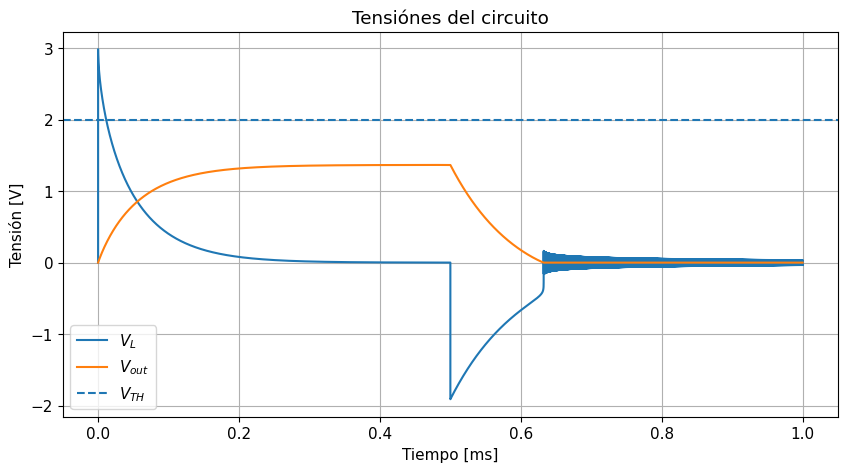

In [182]:
plt.plot(time * 1e3,  v_L, label=r"$V_{L}$")
plt.plot(time * 1e3,  v_out, label=r"$V_{out}$")

plt.axhline(2, linestyle="--", label=r"$V_{TH}$")

plt.xlabel("Tiempo [ms]")
plt.ylabel("Tensión [V]")
plt.title("Tensiónes del circuito")
plt.grid(True)
plt.legend()

plt.show()